# Mini Project Citra Digital — Verifikasi Ijazah (OCR + Deteksi Tanda Tangan)

**Nama:** Muhammad Yani  **NIM:** F1G124069

Input: citra ijazah → Output: **Nomor Ijazah** (OCR) dan **Tanda Tangan** (PRESENT / ABSENT).

```
Citra Ijazah → Grayscale → Image Enhancement
      ├─ Area Nomor → Enhancement → OCR → Nomor Ijazah
      └─ Area Tanda Tangan → Thresholding → Morphology → Signature Detection
                         ↓
                 Hasil Verifikasi
```

## Sel 1 — Instalasi (hanya perlu di Google Colab)

In [1]:
import sys, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run("apt-get install -y -q tesseract-ocr", shell=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pytesseract", "opencv-python", "matplotlib"])
    print("Instalasi selesai.")
else:
    print("Bukan Colab: pastikan Tesseract OCR + `pip install -r requirements.txt` sudah terpasang (lihat README.md).")

Bukan Colab: pastikan Tesseract OCR + `pip install -r requirements.txt` sudah terpasang (lihat README.md).


## Sel 2 — Import dan muat citra

In [2]:
import glob, os, re
import cv2, numpy as np, pandas as pd
import pytesseract
import matplotlib.pyplot as plt

paths = sorted(glob.glob("data/*.jpg") + glob.glob("data/*.jpeg") + glob.glob("data/*.png"))
if not paths and IN_COLAB:
    from google.colab import files
    paths = list(files.upload().keys())
print(f"{len(paths)} citra dimuat:")
for p in paths:
    print(" -", p)

3 citra dimuat:
 - data/ijazah_001.jpg
 - data/ijazah_hanya_dekan.jpg
 - data/ijazah_tanpa_ttd.jpg


## Sel 3 — Grayscale dan Image Enhancement (global)

In [3]:
def orient_gray_enhance(path):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    if img.shape[0] > img.shape[1]:                       # portrait -> landscape
        img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (41, 41))
    bg = cv2.GaussianBlur(cv2.morphologyEx(gray, cv2.MORPH_CLOSE, k), (0, 0), 21)
    norm = cv2.divide(gray, bg, scale=255)
    enh = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(norm)
    return img, gray, enh

data = {}
for p in paths:
    img, gray, enh = orient_gray_enhance(p)
    data[os.path.basename(p)] = dict(img=img, gray=gray, enh=enh)
print("Grayscale + enhancement selesai untuk", len(data), "citra.")

Grayscale + enhancement selesai untuk 3 citra.


## Sel 4 — Pemotongan area (ROI)

In [4]:
ROI_NOMOR  = (0.04, 0.89, 0.36, 0.96)     # baris "Nomor ijazah: ..."
ROI_REKTOR = (0.14, 0.71, 0.40, 0.825)    # area tanda tangan Rektor
ROI_DEKAN  = (0.62, 0.695, 0.90, 0.835)   # area tanda tangan Dekan

def crop_rel(img, roi):
    h, w = img.shape[:2]
    x1, y1, x2, y2 = roi
    return img[int(y1*h):int(y2*h), int(x1*w):int(x2*w)].copy()

for name, d in data.items():
    d["roi_nomor"]  = crop_rel(d["gray"], ROI_NOMOR)    # jalur nomor memakai gray asli
    d["roi_rektor"] = crop_rel(d["enh"], ROI_REKTOR)    # jalur TTD memakai hasil enhancement
    d["roi_dekan"]  = crop_rel(d["enh"], ROI_DEKAN)
print("ROI nomor, rektor, dan dekan selesai dipotong.")

ROI nomor, rektor, dan dekan selesai dipotong.


## Sel 5 — Enhancement area nomor + OCR

In [5]:
def adaptive_gaussian(g):
    return cv2.adaptiveThreshold(cv2.GaussianBlur(g, (3, 3), 0), 255,
                                 cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 15)

FIX = str.maketrans("OoIlSBZ", "0011582")     # huruf yang sering tertukar dengan angka

def extract_number(raw):
    body = raw.split(":", 1)[-1] if ":" in raw else raw      # buang label "Nomor ijazah"
    cleaned = re.sub(r"[\s.,\-:;]", "", body.translate(FIX))
    found = re.findall(r"\d{10,}", cleaned)
    return max(found, key=len) if found else ""

def read_number(roi):
    pad = cv2.copyMakeBorder(roi, 20, 20, 20, 20, cv2.BORDER_CONSTANT, value=int(np.median(roi)))
    raw = ""
    for psm in (7, 6):
        raw = pytesseract.image_to_string(pad, lang="eng", config=f"--oem 3 --psm {psm}").strip()
        num = extract_number(raw)
        if num:
            return num, raw
    return "", raw

for name, d in data.items():
    d["nomor_enh"] = adaptive_gaussian(d["roi_nomor"])
    d["nomor"], d["ocr_raw"] = read_number(d["nomor_enh"])
    print(f"{name:28s} OCR mentah: {d['ocr_raw']!r}  ->  {d['nomor'] or 'TIDAK TERBACA'}")

ijazah_001.jpg               OCR mentah: 'Nomor ijazah: 571012022000056'  ->  571012022000056


ijazah_hanya_dekan.jpg       OCR mentah: 'Nomor ijazah: 571012022000056'  ->  571012022000056


ijazah_tanpa_ttd.jpg         OCR mentah: 'Nomor ijazah: 571012022000056'  ->  571012022000056


## Sel 6 — Deteksi tanda tangan: Thresholding → Morphology → Signature Detection
1. **Thresholding:** *black-hat* (closing − citra) menonjolkan goresan gelap tipis di atas kertas; ambang = max(Otsu, 35). Batas 35 mencegah Otsu "memaksa" memisahkan tekstur kertas ketika area sebenarnya kosong.
2. **Morphology:** *opening* membuang bintik noise, *closing* menyambung goresan yang putus.
3. **Signature detection:** *connected components*. PRESENT jika komponen terbesar punya bounding box ≥ 28% lebar dan ≥ 20% tinggi ROI, dan kepadatan tinta ≥ 1%. Teks cetak berupa komponen-komponen kecil sehingga tidak lolos.

In [6]:
def deteksi_ttd(roi, min_w=0.28, min_h=0.20, min_ink=1.0):
    h, w = roi.shape
    g = cv2.GaussianBlur(roi, (5, 5), 0)
    ks = max(15, int(0.04 * w)) | 1
    bh = cv2.morphologyEx(g, cv2.MORPH_BLACKHAT, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ks, ks)))
    otsu, _ = cv2.threshold(bh, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    mask = ((bh > max(otsu, 35)) * 255).astype(np.uint8)                         # thresholding
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11)))  # morphology
    ink = 100.0 * np.count_nonzero(mask) / (h * w)
    _, _, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    comps = [s for s in stats[1:] if s[cv2.CC_STAT_AREA] >= 0.004 * h * w]
    if not comps:
        return dict(present=False, ink=ink, w=0.0, h=0.0, mask=mask)
    big = max(comps, key=lambda s: s[cv2.CC_STAT_WIDTH] * s[cv2.CC_STAT_HEIGHT])
    wr, hr = big[cv2.CC_STAT_WIDTH] / w, big[cv2.CC_STAT_HEIGHT] / h
    return dict(present=bool(wr >= min_w and hr >= min_h and ink >= min_ink), ink=ink, w=wr, h=hr, mask=mask)

for name, d in data.items():
    d["rektor"], d["dekan"] = deteksi_ttd(d["roi_rektor"]), deteksi_ttd(d["roi_dekan"])
    d["status_ttd"] = "PRESENT" if (d["rektor"]["present"] or d["dekan"]["present"]) else "ABSENT"
    print(f"{name:28s} Rektor: {d['rektor']['present']!s:5} (tinta {d['rektor']['ink']:5.2f}%)   "
          f"Dekan: {d['dekan']['present']!s:5} (tinta {d['dekan']['ink']:5.2f}%)")

ijazah_001.jpg               Rektor: True  (tinta  4.58%)   Dekan: True  (tinta 10.43%)
ijazah_hanya_dekan.jpg       Rektor: False (tinta  0.00%)   Dekan: True  (tinta 10.43%)
ijazah_tanpa_ttd.jpg         Rektor: False (tinta  0.00%)   Dekan: False (tinta  0.18%)


## Sel 7 — Hasil verifikasi (format soal)
Tanda tangan dinyatakan **PRESENT** jika minimal satu pejabat (Rektor/Dekan) terdeteksi.

In [7]:
for name, d in data.items():
    print(f"Input : {name}")
    print("Output:")
    print(f"Nomor Ijazah : {d['nomor'] or 'TIDAK TERBACA'}")
    print(f"Tanda Tangan : {d['status_ttd']}")
    print("-" * 40)

Input : ijazah_001.jpg
Output:
Nomor Ijazah : 571012022000056
Tanda Tangan : PRESENT
----------------------------------------
Input : ijazah_hanya_dekan.jpg
Output:
Nomor Ijazah : 571012022000056
Tanda Tangan : PRESENT
----------------------------------------
Input : ijazah_tanpa_ttd.jpg
Output:
Nomor Ijazah : 571012022000056
Tanda Tangan : ABSENT
----------------------------------------


## Sel 8 — Visualisasi tiap tahap

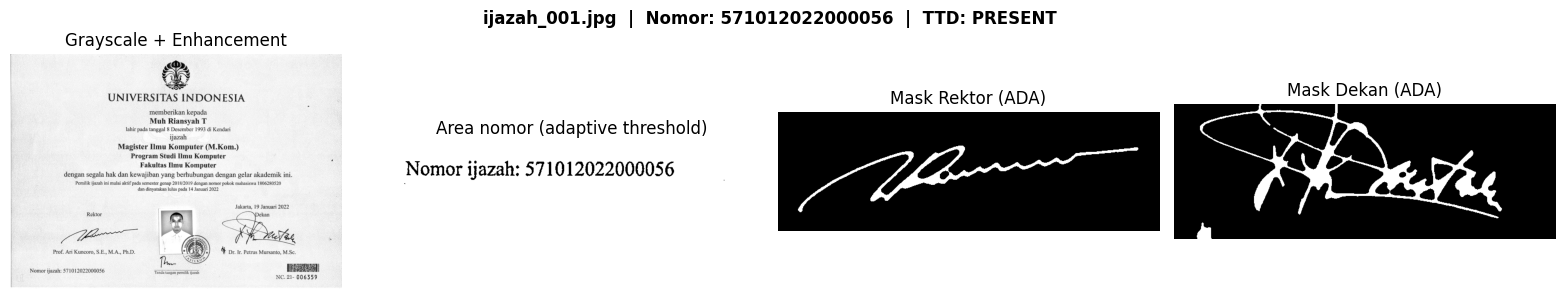

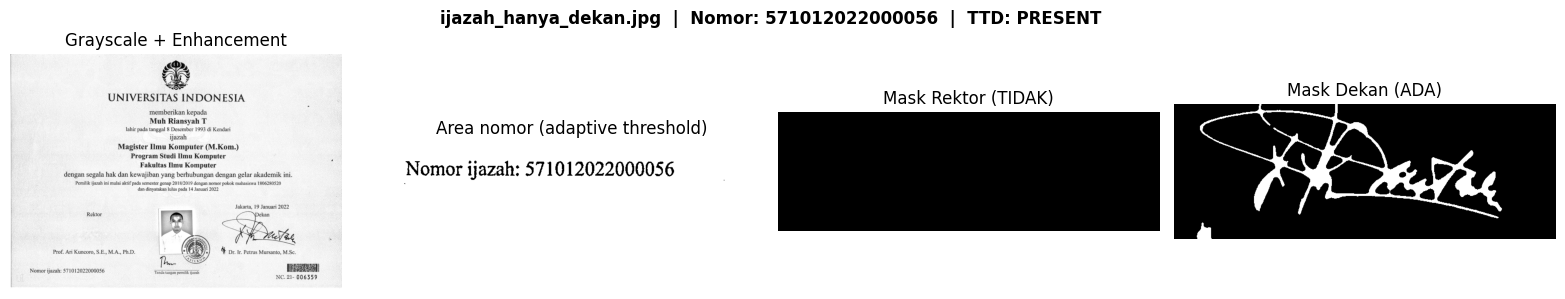

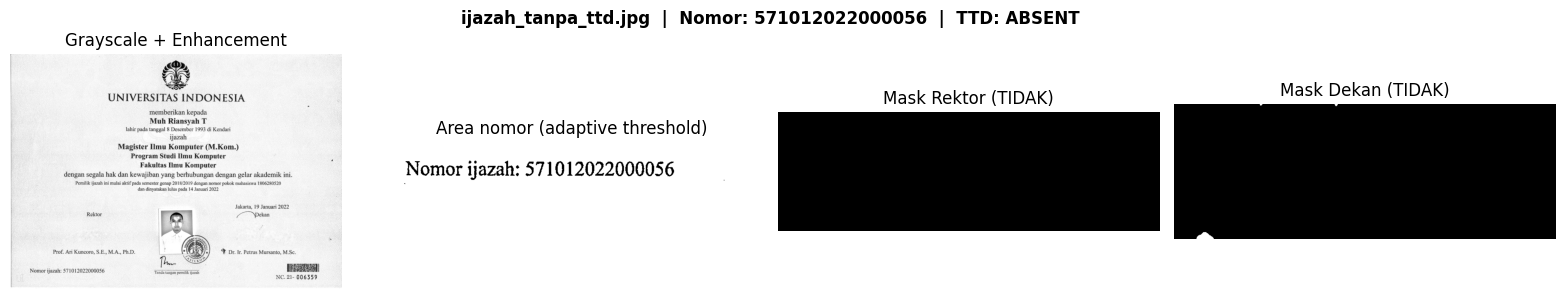

In [8]:
for name, d in data.items():
    fig, ax = plt.subplots(1, 4, figsize=(16, 3))
    fig.suptitle(f"{name}  |  Nomor: {d['nomor']}  |  TTD: {d['status_ttd']}", fontweight="bold")
    ax[0].imshow(d["enh"], cmap="gray");          ax[0].set_title("Grayscale + Enhancement")
    ax[1].imshow(d["nomor_enh"], cmap="gray");    ax[1].set_title("Area nomor (adaptive threshold)")
    ax[2].imshow(d["rektor"]["mask"], cmap="gray"); ax[2].set_title(f"Mask Rektor ({'ADA' if d['rektor']['present'] else 'TIDAK'})")
    ax[3].imshow(d["dekan"]["mask"], cmap="gray");  ax[3].set_title(f"Mask Dekan ({'ADA' if d['dekan']['present'] else 'TIDAK'})")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()

## Sel 9 — Evaluasi CER: metode enhancement mana yang paling efektif?

In [9]:
GROUND_TRUTH = "571012022000056"      # ubah jika memakai ijazah lain

def levenshtein(a, b):
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(prev[j] + 1, cur[j-1] + 1, prev[j-1] + (ca != cb)))
        prev = cur
    return prev[-1]

def cer(pred, truth):
    return levenshtein(pred, truth) / len(truth)

# ---- 6 metode enhancement ----
METHODS = {
    "gray_saja":         lambda g: g,
    "hist_equalization": lambda g: cv2.equalizeHist(g),
    "clahe":             lambda g: cv2.createCLAHE(2.0, (4, 4)).apply(g),
    "gaussian_otsu":     lambda g: cv2.threshold(cv2.GaussianBlur(g, (3, 3), 0), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1],
    "adaptive_gaussian": adaptive_gaussian,
    "upscale_gauss_otsu": lambda g: cv2.threshold(cv2.GaussianBlur(cv2.resize(g, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC), (5, 5), 0), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1],
}

# ---- 9 kondisi degradasi ----
def d_blur(g, r):  return cv2.GaussianBlur(g, (0, 0), 2.2)
def d_noise(g, r): return np.clip(g + r.normal(0, 28, g.shape), 0, 255).astype(np.uint8)
def d_lowcon(g, r): return np.clip(150 + 0.30 * (g.astype(np.float32) - 128), 0, 255).astype(np.uint8)
def d_uneven(g, r):
    ramp = np.tile(np.linspace(0.35, 1.15, g.shape[1], dtype=np.float32), (g.shape[0], 1))
    return np.clip(g * ramp, 0, 255).astype(np.uint8)
def d_jpeg(g, r):
    _, enc = cv2.imencode(".jpg", g, [cv2.IMWRITE_JPEG_QUALITY, 6])
    return cv2.imdecode(enc, cv2.IMREAD_GRAYSCALE)
def d_lowres(g, r): return cv2.resize(g, None, fx=0.30, fy=0.30, interpolation=cv2.INTER_AREA)
def d_saltpepper(g, r):
    o, m = g.copy(), r.random(g.shape)
    o[m < 0.03] = 0; o[m > 0.97] = 255
    return o
def d_combo(g, r): return d_noise(d_blur(d_uneven(g, r), r), r)      # iluminasi + blur + noise
SCENARIOS = {"clean": lambda g, r: g, "blur": d_blur, "noise": d_noise,
             "low_contrast": d_lowcon, "uneven_light": d_uneven, "low_res": d_lowres,
             "jpeg_q6": d_jpeg, "salt_pepper": d_saltpepper, "kombinasi": d_combo}

# citra bersih yang dievaluasi: ijazah_001 (atau citra pertama)
eval_name = next((n for n in data if "001" in n), next(iter(data)))
base = data[eval_name]["roi_nomor"]
SEEDS = 5
table = pd.DataFrame(0.0, index=list(METHODS), columns=list(SCENARIOS))
for seed in range(SEEDS):
    rng = np.random.default_rng(124069 + seed)
    for sc, f in SCENARIOS.items():
        deg = f(base, rng)
        for m, enh_fn in METHODS.items():
            try:
                pred, _ = read_number(enh_fn(deg))
            except Exception:
                pred = ""
            table.loc[m, sc] += cer(pred, GROUND_TRUTH) / SEEDS

table["rata_rata_CER"] = table.mean(axis=1)
table = table.sort_values("rata_rata_CER").round(3)
print(f"Citra evaluasi: {eval_name} | ground truth: {GROUND_TRUTH}")
table

Citra evaluasi: ijazah_001.jpg | ground truth: 571012022000056


,clean,blur,noise,low_contrast,uneven_light,low_res,jpeg_q6,salt_pepper,kombinasi,rata_rata_CER
adaptive_gaussian,0.0,0.0,0.253,0.000,0.000,0.000,0.0,0.427,0.120,0.089
gray_saja,0.0,0.0,0.013,0.000,0.267,0.000,0.0,0.453,0.827,0.173
gaussian_otsu,0.0,0.0,0.000,0.000,1.000,0.133,0.0,0.040,0.867,0.227
clahe,0.0,0.0,0.480,0.000,1.000,0.000,0.0,0.040,0.653,0.241
upscale_gauss_otsu,0.0,0.0,0.013,0.000,1.000,0.000,0.0,1.000,1.000,0.335
hist_equalization,0.0,1.0,0.587,0.333,1.000,1.000,1.0,1.000,1.000,0.769


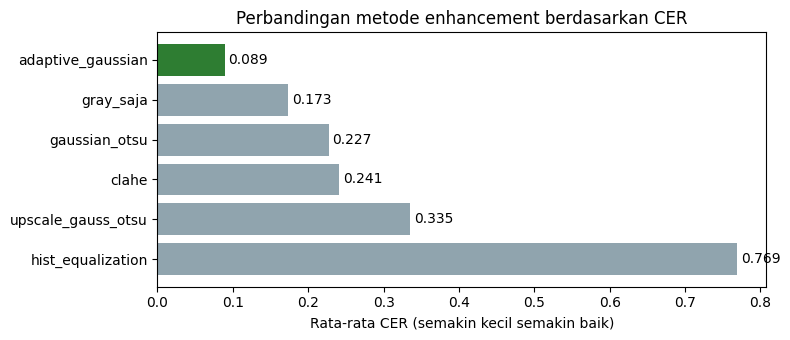

Metode paling efektif: adaptive_gaussian (rata-rata CER = 0.089)


In [10]:
best = table.index[0]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(table.index[::-1], table["rata_rata_CER"][::-1],
        color=["#2e7d32" if m == best else "#90a4ae" for m in table.index[::-1]])
for i, v in enumerate(table["rata_rata_CER"][::-1]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
ax.set_xlabel("Rata-rata CER (semakin kecil semakin baik)")
ax.set_title("Perbandingan metode enhancement berdasarkan CER")
plt.tight_layout(); plt.show()
print(f"Metode paling efektif: {best} (rata-rata CER = {table.loc[best, 'rata_rata_CER']:.3f})")